# Backtest d'une stratégie Momentum sur AAPL

Stratégie : signal momentum sur 120 jours (achat si rendement passé sur 120 jours > 0, sinon position neutre), comparée à une stratégie buy & hold sur l'action Apple (AAPL).


In [1]:
import sys
!{sys.executable} -m pip install yfinance --quiet


In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import scipy.stats as stats
from IPython.display import display, HTML


## 1. Récupération des données AAPL

In [3]:
apple = yf.download("AAPL", start="2018-01-01", end="2025-01-01")

# yfinance renvoie parfois des colonnes en MultiIndex meme pour un seul ticker -> on les aplatit
if isinstance(apple.columns, pd.MultiIndex):
    apple.columns = apple.columns.get_level_values(0)

apple.head()


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2018-01-02,40.267078,40.276431,39.565806,39.776190,102223600
2018-01-03,40.260059,40.802379,40.196947,40.330187,118071600
2018-01-04,40.447075,40.549929,40.225006,40.332532,89738400
2018-01-05,40.907581,40.994071,40.451755,40.542920,94640000
2018-01-08,40.755630,41.050164,40.657449,40.755630,82271200


## 2. Rendements et performance buy & hold

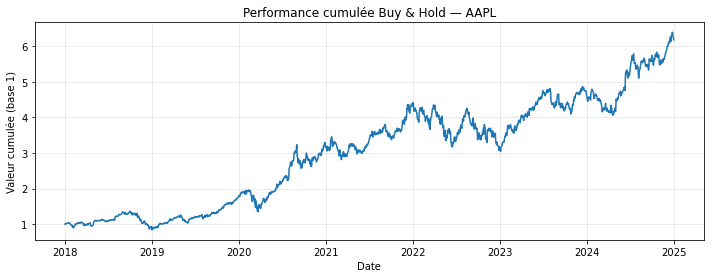

In [4]:
apple["return"] = apple["Close"].pct_change()
apple["cum_return"] = (1 + apple["return"]).cumprod()

plt.figure(figsize=(12, 4))
plt.plot(apple["cum_return"])
plt.title("Performance cumulée Buy & Hold — AAPL")
plt.xlabel("Date")
plt.ylabel("Valeur cumulée (base 1)")
plt.grid(alpha=0.3)
plt.show()


## 3. Signal momentum

Idée : si l'action monte depuis 120 jours de bourse, on se positionne acheteur ; sinon on reste hors marché.

In [5]:
apple["momentum"] = apple["Close"].pct_change(120)
apple["signal"] = (apple["momentum"] > 0)

# Le signal est décalé d'un jour (shift) pour éviter le look-ahead bias :
# on ne peut trader qu'avec l'information disponible la veille.
apple["strategy_return"] = apple["signal"].shift(1) * apple["return"]
apple["strategy_cum"] = (1 + apple["strategy_return"]).cumprod()


In [6]:
"""
Analyse complémentaire pour répondre à la remarque :
"la stratégie sous-performe l'action sur tout l'historique"

A coller après la cellule où 'apple' et 'strategy_return' existent déjà
dans ton notebook (après l'étape 4 : calcul de strategy_return).
"""

import numpy as np
import pandas as pd

# ---------------------------------------------------------------
# 1. Métriques risque-ajusté : Sharpe, Sortino, Calmar
#    (sur la stratégie ET sur le buy & hold, pour comparaison directe)
# ---------------------------------------------------------------

def perf_metrics(returns: pd.Series, label: str) -> dict:
    returns = returns.dropna()
    ann_return = (1 + returns.mean()) ** 252 - 1
    ann_vol = returns.std() * np.sqrt(252)
    sharpe = ann_return / ann_vol if ann_vol > 0 else np.nan

    downside = returns[returns < 0]
    downside_vol = downside.std() * np.sqrt(252) if len(downside) > 0 else np.nan
    sortino = ann_return / downside_vol if downside_vol else np.nan

    cum = (1 + returns).cumprod()
    roll_max = cum.cummax()
    drawdown = cum / roll_max - 1
    max_dd = drawdown.min()
    calmar = ann_return / abs(max_dd) if max_dd != 0 else np.nan

    return {
        "Stratégie": label,
        "Rendement annualisé": f"{ann_return:.2%}",
        "Volatilité annualisée": f"{ann_vol:.2%}",
        "Sharpe": round(sharpe, 3),
        "Sortino": round(sortino, 3),
        "Max Drawdown": f"{max_dd:.2%}",
        "Calmar": round(calmar, 3),
    }

buy_hold_return = apple["return"].dropna()
strat_return = apple["strategy_return"].dropna()

comparison = pd.DataFrame([
    perf_metrics(buy_hold_return, "Buy & Hold"),
    perf_metrics(strat_return, "Momentum 120j"),
])
print(comparison.to_string(index=False))

# ---------------------------------------------------------------
# 2. Découpage par sous-périodes (régimes de marché)
#    Adapte les dates si tu veux d'autres bornes.
# ---------------------------------------------------------------

regimes = {
    "Bull 2018-2019 (hors Q4 2018)": ("2018-01-01", "2018-09-30"),
    "Correction Q4 2018":            ("2018-10-01", "2018-12-31"),
    "Bull 2019-2021 (incl. COVID crash)": ("2019-01-01", "2021-12-31"),
    "Bear 2022":                     ("2022-01-01", "2022-12-31"),
    "Reprise 2023-2024":             ("2023-01-01", "2025-01-01"),
}

rows = []
for name, (start, end) in regimes.items():
    mask = (apple.index >= start) & (apple.index < end)
    bh = apple.loc[mask, "return"].dropna()
    st = apple.loc[mask, "strategy_return"].dropna()
    if len(bh) == 0:
        continue
    bh_cum = (1 + bh).prod() - 1
    st_cum = (1 + st).prod() - 1
    rows.append({
        "Période": name,
        "Buy & Hold (cumulé)": f"{bh_cum:.2%}",
        "Momentum (cumulé)": f"{st_cum:.2%}",
        "Écart (Momentum - B&H)": f"{(st_cum - bh_cum):.2%}",
    })

regime_table = pd.DataFrame(rows)
print()
print(regime_table.to_string(index=False))

# ---------------------------------------------------------------
# 3. Test de robustesse rapide : sensibilité à la fenêtre momentum
#    (pour répondre à "le paramètre 120j n'est pas optimisé")
# ---------------------------------------------------------------

results = []
for window in [40, 60, 90, 120, 150, 200, 252]:
    sig = (apple["Close"].pct_change(window) > 0)
    strat_ret = sig.shift(1) * apple["return"]
    strat_ret = strat_ret.dropna()
    ann_ret = (1 + strat_ret.mean()) ** 252 - 1
    ann_vol = strat_ret.std() * np.sqrt(252)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else np.nan
    results.append({"Fenêtre (jours)": window, "Rendement annualisé": f"{ann_ret:.2%}", "Sharpe": round(sharpe, 3)})

sensitivity = pd.DataFrame(results)
print()
print(sensitivity.to_string(index=False))

    Stratégie Rendement annualisé Volatilité annualisée  Sharpe  Sortino Max Drawdown  Calmar
   Buy & Hold              35.98%                30.55%   1.178    1.635      -38.52%   0.934
Momentum 120j              15.11%                25.84%   0.585    0.671      -44.00%   0.343

                           Période Buy & Hold (cumulé) Momentum (cumulé) Écart (Momentum - B&H)
     Bull 2018-2019 (hors Q4 2018)              32.55%            24.35%                 -8.20%
                Correction Q4 2018             -30.55%           -23.22%                  7.33%
Bull 2019-2021 (incl. COVID crash)             365.49%           219.17%               -146.32%
                         Bear 2022             -26.40%           -38.54%                -12.13%
                 Reprise 2023-2024              94.76%            13.40%                -81.36%

 Fenêtre (jours) Rendement annualisé  Sharpe
              40              19.12%   0.918
              60              21.12%   0.934
     

## 4. Comparaison stratégie vs Buy & Hold

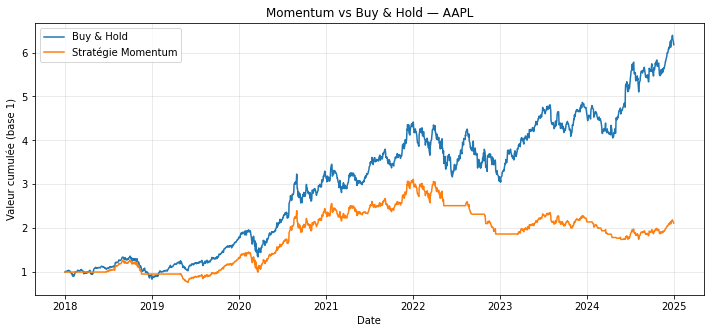

In [7]:
plt.figure(figsize=(12, 5))
plt.plot(apple["cum_return"], label="Buy & Hold")
plt.plot(apple["strategy_cum"], label="Stratégie Momentum")
plt.title("Momentum vs Buy & Hold — AAPL")
plt.xlabel("Date")
plt.ylabel("Valeur cumulée (base 1)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [8]:
# IMPORTANT : on travaille bien sur le rendement de la STRATEGIE, pas du buy & hold
strategy_return = apple["strategy_return"].dropna()


## 5. Sharpe Ratio

In [9]:
sharpe = (strategy_return.mean() / strategy_return.std()) * np.sqrt(252)
print(f"Sharpe Ratio (non annualisé->annualisé) : {sharpe:.4f}")


Sharpe Ratio (non annualisé->annualisé) : 0.5448


## 6. Max Drawdown

In [10]:
strategy_cum = (1 + strategy_return).cumprod()
rolling_max = strategy_cum.cummax()
drawdown = strategy_cum / rolling_max - 1
max_drawdown = drawdown.min()
print(f"Max Drawdown : {max_drawdown:.2%}")


Max Drawdown : -44.00%


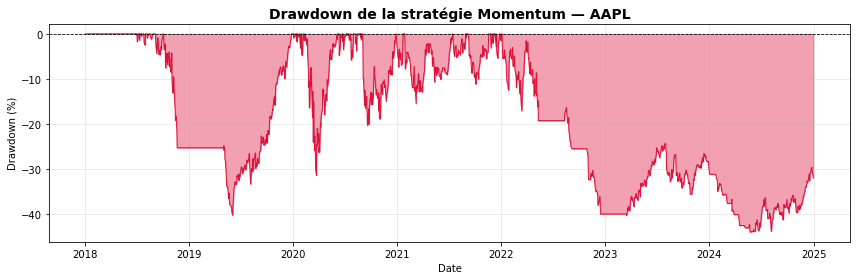

In [11]:
fig, ax = plt.subplots(figsize=(12, 4))

# Conversion explicite en arrays numpy natifs (évite un bug numpy/matplotlib
# avec masked_invalid sur un DatetimeIndex pandas dans certains environnements)
x = drawdown.index.to_pydatetime()
y = drawdown.values.astype(float) * 100

ax.fill_between(x, y, 0, color='crimson', alpha=0.4)
ax.plot(x, y, color='crimson', linewidth=1)
ax.set_title("Drawdown de la stratégie Momentum — AAPL", fontsize=14, fontweight='bold')
ax.set_ylabel("Drawdown (%)")
ax.set_xlabel("Date")
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 7. VaR et Expected Shortfall de la stratégie

In [12]:
confidence = 0.95

# VaR historique
VaR_hist = np.percentile(strategy_return, (1 - confidence) * 100)

# Expected Shortfall (CVaR) historique
ES_hist = strategy_return[strategy_return <= VaR_hist].mean()

# VaR paramétrique (loi normale)
mu = strategy_return.mean()
sigma = strategy_return.std()
VaR_param = stats.norm.ppf(1 - confidence, mu, sigma)

print(f"VaR historique (95%)     : {VaR_hist:.2%}")
print(f"VaR paramétrique (95%)   : {VaR_param:.2%}")
print(f"Expected Shortfall (95%) : {ES_hist:.2%}")


VaR historique (95%)     : -2.54%
VaR paramétrique (95%)   : -2.62%
Expected Shortfall (95%) : -3.99%


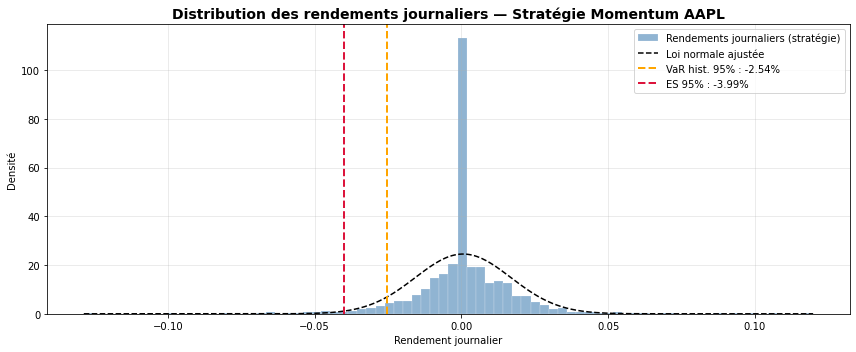

In [13]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(strategy_return, bins=80, color='steelblue', alpha=0.6,
        edgecolor='white', linewidth=0.3, density=True, label='Rendements journaliers (stratégie)')

x = np.linspace(strategy_return.min(), strategy_return.max(), 300)
ax.plot(x, stats.norm.pdf(x, mu, sigma), 'k--', linewidth=1.5, label='Loi normale ajustée')

ax.axvline(VaR_hist, color='orange', linewidth=2, linestyle='--',
           label=f'VaR hist. 95% : {VaR_hist:.2%}')
ax.axvline(ES_hist, color='crimson', linewidth=2, linestyle='--',
           label=f'ES 95% : {ES_hist:.2%}')

ax.set_title("Distribution des rendements journaliers — Stratégie Momentum AAPL", fontsize=14, fontweight='bold')
ax.set_xlabel("Rendement journalier")
ax.set_ylabel("Densité")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 8. Tableau de synthèse

In [14]:
sharpe_annualise = (mu / sigma) * np.sqrt(252)
rendement_annualise = (1 + mu) ** 252 - 1
vol_annualisee = sigma * np.sqrt(252)

metrics = {
    "Rendement annualisé"        : f"{rendement_annualise:.2%}",
    "Volatilité annualisée"      : f"{vol_annualisee:.2%}",
    "Sharpe Ratio (annualisé)"   : f"{sharpe_annualise:.4f}",
    "Max Drawdown"               : f"{max_drawdown:.2%}",
    "VaR historique (95%)"       : f"{VaR_hist:.2%}",
    "VaR paramétrique (95%)"     : f"{VaR_param:.2%}",
    "Expected Shortfall (95%)"   : f"{ES_hist:.2%}",
}

df_metrics = pd.DataFrame.from_dict(metrics, orient='index', columns=['Valeur'])
df_metrics.index.name = "Indicateur"

html = df_metrics.to_html()
styled_html = f"""
<style>
  table {{ border-collapse: collapse; width: 50%; font-family: Arial; }}
  caption {{ font-size: 14px; font-weight: bold; margin-bottom: 8px; }}
  th {{ background-color: #2c3e50; color: white; padding: 8px 12px; text-align: left; }}
  td {{ padding: 7px 12px; text-align: right; border-bottom: 1px solid #ddd; }}
  tr:hover {{ background-color: #f5f5f5; }}
</style>
<caption>Tableau de synthèse — Stratégie Momentum AAPL</caption>
{html}
"""
display(HTML(styled_html))


,Valeur
Indicateur,
Rendement annualisé,15.11%
Volatilité annualisée,25.84%
Sharpe Ratio (annualisé),0.5448
Max Drawdown,-44.00%
VaR historique (95%),-2.54%
VaR paramétrique (95%),-2.62%
Expected Shortfall (95%),-3.99%


## 9. Lecture des indicateurs

| Indicateur | Question à laquelle il répond |
|---|---|
| Rendement annualisé | Combien je gagne ? |
| Volatilité annualisée | De combien ça fluctue ? |
| Sharpe Ratio | Est-ce que ça vaut le risque pris ? |
| Max Drawdown | Quelle est la pire perte historique ? |
| VaR (95%) | Quelle est ma perte un mauvais jour "normal" ? |
| Expected Shortfall | Quelle est ma perte lors d'un jour catastrophique ? |
